# 🚲 Somerville Bike Kitchen — Visitor Sign-In Analysis

This notebook breaks down visitor sign-in data step by step. Each section is independent — you can re-run any cell on its own after changing parameters.

**Sections:**
1. Setup & Imports
2. Load & Clean Data
3. Summary Stats
4. Visits Over Time
5. Where Visitors Come From
6. How Visitors Arrived
7. Visit Reasons
8. New vs. Returning Visitors
9. Email Opt-ins & Volunteer Interest
10. Peak Hours
11. Unique Visitors per Year
12. All Charts Together

## 1. Setup & Imports
Install and import the libraries we need. You only need to run the `pip install` line once.

In [1]:
# Uncomment and run this line once if you haven't installed these libraries yet
# !pip install pandas matplotlib

In [2]:
import pandas as pd                    # Core data analysis library (DataFrames)
import matplotlib.pyplot as plt        # Chart drawing
import matplotlib.dates as mdates      # Date formatting helpers for charts
from collections import Counter        # Tallies items in a list

# This tells Jupyter to display charts inline in the notebook (not in a popup window)
%matplotlib inline

## 2. Load & Clean Data

**⚠️ Update `RAW_DATA` below** to point to where you saved the CSV on your Mac.

Tip: drag the file into Terminal to get its exact path, then paste it here.

In [3]:
import os

# Find the CSV file inside the Kaggle dataset folder
folder = "/kaggle/input/datasets/hgoldberg15/visitor-sign-in-data-as-of-march-2026"
csv_files = [f for f in os.listdir(folder) if f.endswith(".csv")]
CSV_PATH = os.path.join(folder, csv_files[0])

print(f"Loading: {CSV_PATH}")

# Load the CSV into a DataFrame (think: spreadsheet in memory)
df = pd.read_csv(CSV_PATH)


# Rename the long Google Form column headers to short, clean names.
# Order must match the CSV column order exactly.
df.columns = [
    "timestamp", "email", "origin", "arrival_mode",
    "visit_reasons", "first_visit", "first_name", "last_name",
    "email_opt_in", "volunteer_interest",
]

# Convert the timestamp column from plain text → real datetime objects.
# errors="coerce" turns anything unparseable into NaT instead of crashing.
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Drop rows where the timestamp couldn't be parsed
df = df.dropna(subset=["timestamp"])

# Extract useful time components into their own columns for easy grouping
df["date"]  = df["timestamp"].dt.date           # e.g. 2026-03-20
df["year"]  = df["timestamp"].dt.year           # e.g. 2026
df["month"] = df["timestamp"].dt.to_period("M") # e.g. 2026-03
df["week"]  = df["timestamp"].dt.to_period("W") # e.g. week of 2026-03-16
df["hour"]  = df["timestamp"].dt.hour           # e.g. 18 (= 6 PM)

# Strip leading/trailing whitespace from text columns.
# astype(str) first handles any NaN values that would otherwise cause errors.
for col in ["origin", "arrival_mode", "first_visit", "email_opt_in", "volunteer_interest"]:
    df[col] = df[col].astype(str).str.strip()

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading: /kaggle/input/datasets/hgoldberg15/visitor-sign-in-data-as-of-march-2026/Visitor Sign In (Responses) 2025 - Form Responses 5.csv
✅ Data loaded successfully!
Shape: 6,137 rows × 15 columns


### Preview the data
Always worth a quick look to confirm everything loaded as expected.

In [4]:
# .head() shows the first 5 rows by default. Change the number to see more.
df.head(10)

,timestamp,email,origin,arrival_mode,visit_reasons,first_visit,first_name,last_name,email_opt_in,volunteer_interest,date,year,month,week,hour
0,2026-03-20 10:36:14,visitor@sbk.org,Somerville,Cycling or walking,Education & Instruction,No,NaN,NaN,nan,nan,2026-03-20,2026,2026-03,2026-03-16/2026-03-22,10
1,2026-03-19 21:28:32,danieliwvernick@gmail.com,Somerville,Cycling or walking,"Save $ & Self-reliance, Community & Social, Us...",No,NaN,NaN,nan,nan,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,21
2,2026-03-19 20:45:59,lucy2702.qiu@gmail.com,Somerville,Cycling or walking,Save $ & Self-reliance,No,NaN,NaN,nan,nan,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,20
3,2026-03-19 20:17:17,visitor@somervillebikekitchen.org,Somerville,Cycling or walking,I'm here to volunteer!,No,NaN,NaN,nan,nan,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,20
4,2026-03-19 20:14:13,dorismlee4@gmail.com,Somerville,Cycling or walking,Save $ & Self-reliance,Yes,Doris,Lee,Yes,No,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,20
5,2026-03-19 20:06:43,kqmckenna123@gmail.com,Somerville,Cycling or walking,Save $ & Self-reliance,No,NaN,NaN,nan,nan,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,20
6,2026-03-19 19:14:40,emma_caviness@alumni.brown.edu,Boston,Cycling or walking,Use Your Tools!,Yes,Emma,Caviness,Yes,No,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,19
7,2026-03-19 19:14:23,sadyeb99@gmail.com,Somerville,Cycling or walking,"Save $ & Self-reliance, Use Your Tools!",No,NaN,NaN,nan,nan,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,19
8,2026-03-19 19:09:07,laurenloon2000@gmail.com,Cambridge,Cycling or walking,"Education & Instruction, Save $ & Self-relianc...",Yes,Lauren,Looney,Yes,No,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,19
9,2026-03-19 19:08:33,laurenloon2000@gmail.com,Cambridge,Cycling or walking,"Education & Instruction, Save $ & Self-relianc...",Yes,Lauren,Looney,Yes,Yes,2026-03-19,2026,2026-03,2026-03-16/2026-03-22,19


In [5]:
# .dtypes shows the data type of each column — useful for catching loading issues.
# 'datetime64[ns]' confirms the timestamp parsed correctly.
df.dtypes

timestamp             datetime64[ns]
email                         object
origin                        object
arrival_mode                  object
visit_reasons                 object
first_visit                   object
first_name                    object
last_name                     object
email_opt_in                  object
volunteer_interest            object
date                          object
year                           int32
month                      period[M]
week                   period[W-SUN]
hour                           int32
dtype: object

## 3. Summary Stats
A quick top-level overview before diving into individual analyses.

In [6]:
print(f"Total sign-ins : {len(df):,}")
print(f"Date range     : {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
# .nunique() counts distinct values — emails here gives us unique visitor count
print(f"Unique visitors: {df['email'].nunique():,}  (deduplicated by email)")
print(f"Years covered  : {sorted(df['year'].unique())}")

Total sign-ins : 6,137
Date range     : 2019-01-10 → 2026-03-20
Unique visitors: 2,819  (deduplicated by email)
Years covered  : [np.int32(2019), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]


## 4. Visits Over Time

In [7]:
# Visits per year
# .value_counts() counts occurrences of each year, .sort_index() puts them in order
yearly = df["year"].value_counts().sort_index()
print("=== Visits per Year ===")
print(yearly.to_string())

=== Visits per Year ===
year
2019     266
2021       2
2022     368
2023    1293
2024    1748
2025    2214
2026     246


In [8]:
# Monthly visits — tweak the number of months by changing the value below
MONTHS_BACK = 12   # ← change this to see a different window

# pd.DateOffset subtracts a time span from a date
last_n = df[df["timestamp"] >= df["timestamp"].max() - pd.DateOffset(months=MONTHS_BACK)]

# .groupby().size() groups rows by month and counts them
monthly = last_n.groupby("month").size().sort_index()

print(f"=== Monthly Visits (last {MONTHS_BACK} months) ===")
print(monthly.to_string())

=== Monthly Visits (last 12 months) ===
month
2025-03     96
2025-04    260
2025-05    270
2025-06    168
2025-07    218
2025-08    272
2025-09    222
2025-10    196
2025-11    111
2025-12     67
2026-01     96
2026-02     49
2026-03    101
Freq: M


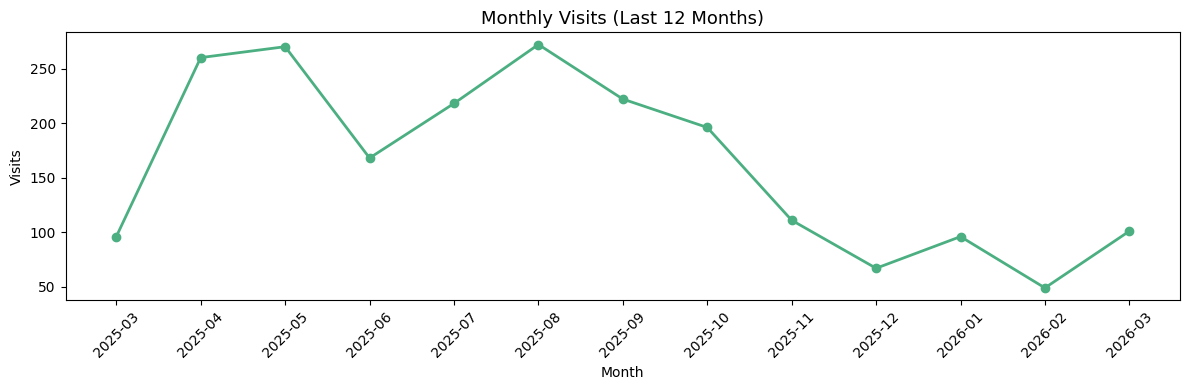

In [9]:
# Plot monthly visits as a line chart
fig, ax = plt.subplots(figsize=(12, 4))

# .astype(str) converts Period objects to strings so matplotlib can label the x-axis
ax.plot(monthly.index.astype(str), monthly.values, marker="o", color="#4CAF82", linewidth=2)
ax.set_title(f"Monthly Visits (Last {MONTHS_BACK} Months)", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Visits")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 4.5 Now I want to look at seasonality over the years:

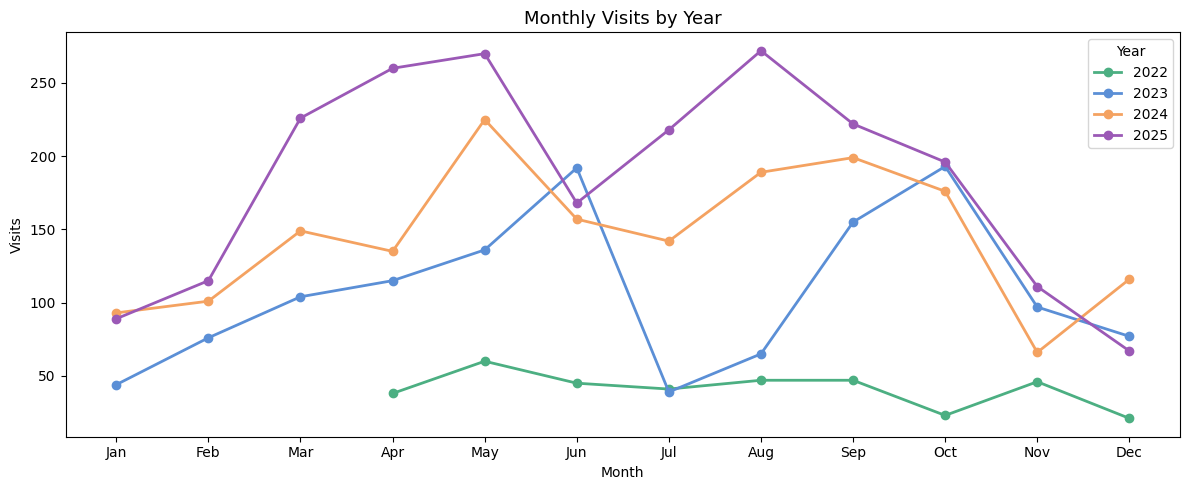

In [10]:
# Filter to full years only (exclude 2019 and 2026 if they're partial)
YEARS_TO_PLOT = [2022, 2023, 2024, 2025]  # ← adjust as needed

# Color palette — one color per year
colors = ["#4CAF82", "#5B8FD6", "#F4A261", "#9B59B6", "#E74C3C"]

fig, ax = plt.subplots(figsize=(12, 5))

for i, year in enumerate(YEARS_TO_PLOT):
    # Filter raw_data down to just this year's rows
    year_data = df[df["year"] == year]
    
    # Group by month number (1–12) so all years share the same x-axis
    # .dt.month extracts just the month number from the timestamp
    monthly_counts = year_data.groupby(year_data["timestamp"].dt.month).size()
    
    # Plot this year as its own line
    ax.plot(monthly_counts.index, monthly_counts.values,
            marker="o", linewidth=2,
            color=colors[i % len(colors)],
            label=str(year))

ax.set_title("Monthly Visits by Year", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Visits")

# Replace the month numbers (1–12) with abbreviated month names on the x-axis
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

# Add a legend so you can tell which line is which year
ax.legend(title="Year")

plt.tight_layout()
plt.show()

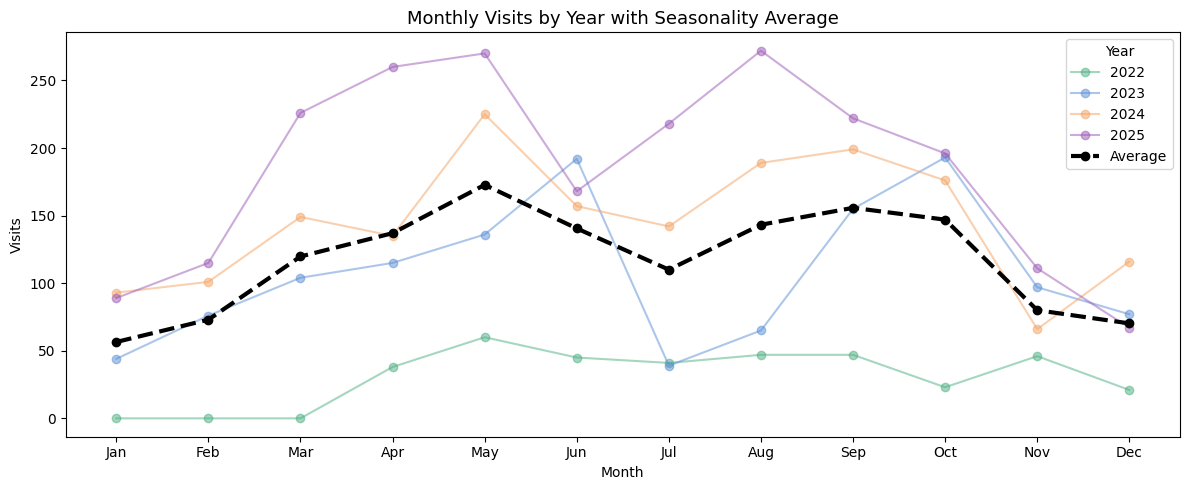

In [11]:
# THIS PART IS TAKING THE AVERAGE OF YEAR AND THEN PLOTTING IT
import numpy as np

YEARS_TO_PLOT = [2022, 2023, 2024, 2025]  # ← adjust as needed
colors = ["#4CAF82", "#5B8FD6", "#F4A261", "#9B59B6"]

fig, ax = plt.subplots(figsize=(12, 5))

# Store each year's monthly counts so we can average them at the end
all_monthly = []

for i, year in enumerate(YEARS_TO_PLOT):
    year_data = df[df["year"] == year]
    monthly_counts = year_data.groupby(year_data["timestamp"].dt.month).size()
    
    # Reindex to ensure all 12 months are present — fills missing months with 0
    # This prevents the average from being skewed by missing months
    monthly_counts = monthly_counts.reindex(range(1, 13), fill_value=0)
    
    all_monthly.append(monthly_counts.values)
    
    # Plot each year as a thin, slightly transparent line
    ax.plot(monthly_counts.index, monthly_counts.values,
            marker="o", linewidth=1.5, alpha=0.5,
            color=colors[i % len(colors)],
            label=str(year))

# Calculate the average across all years for each month
avg_monthly = np.mean(all_monthly, axis=0)

# Plot the average as a bold dashed black line so it stands out
ax.plot(range(1, 13), avg_monthly,
        marker="o", linewidth=3,
        linestyle="--", color="black",
        label="Average")

ax.set_title("Monthly Visits by Year with Seasonality Average", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Visits")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.legend(title="Year")
plt.tight_layout()
plt.show()

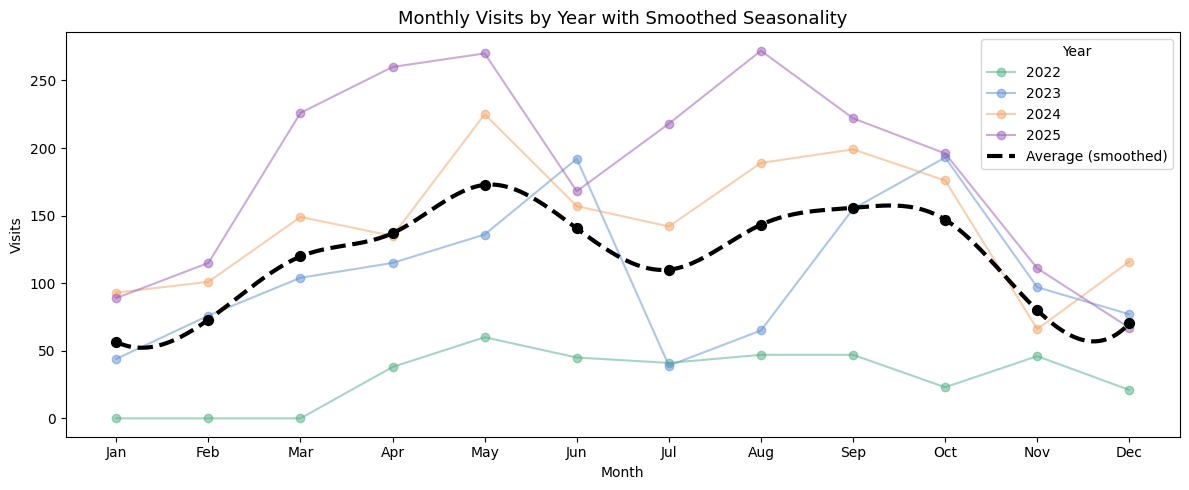

In [12]:
#This uses some modeling techniques to smooth the average line
from scipy.interpolate import make_interp_spline

YEARS_TO_PLOT = [2022, 2023, 2024, 2025]
colors = ["#4CAF82", "#5B8FD6", "#F4A261", "#9B59B6"]

fig, ax = plt.subplots(figsize=(12, 5))

all_monthly = []

for i, year in enumerate(YEARS_TO_PLOT):
    year_data = df[df["year"] == year]
    monthly_counts = year_data.groupby(year_data["timestamp"].dt.month).size()
    monthly_counts = monthly_counts.reindex(range(1, 13), fill_value=0)
    all_monthly.append(monthly_counts.values)

    ax.plot(monthly_counts.index, monthly_counts.values,
            marker="o", linewidth=1.5, alpha=0.5,
            color=colors[i % len(colors)],
            label=str(year))

# Calculate the average across all years
avg_monthly = np.mean(all_monthly, axis=0)
months = np.array(range(1, 13))

# make_interp_spline fits a smooth curve through the 12 average points.
# k=3 means a cubic spline — a degree-3 polynomial curve between each pair of points.
# np.linspace(1, 12, 300) generates 300 evenly spaced x-values between month 1 and 12,
# giving the curve enough points to look smooth rather than segmented.
spline = make_interp_spline(months, avg_monthly, k=3)
smooth_x = np.linspace(1, 12, 300)
smooth_y = spline(smooth_x)

# Plot the smoothed average line
ax.plot(smooth_x, smooth_y,
        linewidth=3, linestyle="--",
        color="black", label="Average (smoothed)")

# Still plot the original average points as dots so the actual values are visible
ax.scatter(months, avg_monthly, color="black", zorder=5, s=50)

ax.set_title("Monthly Visits by Year with Smoothed Seasonality", fontsize=13)
ax.set_xlabel("Month")
ax.set_ylabel("Visits")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.legend(title="Year")
plt.tight_layout()
plt.show()

## 5. Where Visitors Come From

In [13]:
# Filter out blank rows (stored as the string "nan" after our astype(str) step)
origins = df[df["origin"] != "nan"]["origin"].value_counts()

print("=== All Origins ===")
print(origins.to_string())

=== All Origins ===
origin
Somerville                         2959
Cambridge                          1299
Boston                              462
Medford/Arlington                   344
Watertown                           120
Brookline                            39
Belmont                              34
Arlington                            29
Allston                              23
Andover                              19
Newton                               16
Malden                               15
Brighton                             14
Needham                              10
Dorchester                            8
Burlington                            8
Syracuse                              6
Quincy                                4
Lexington                             4
JP                                    4
Jamaica Plain                         3
Salem                                 3
everett                               3
Everett                               3
Waltham      

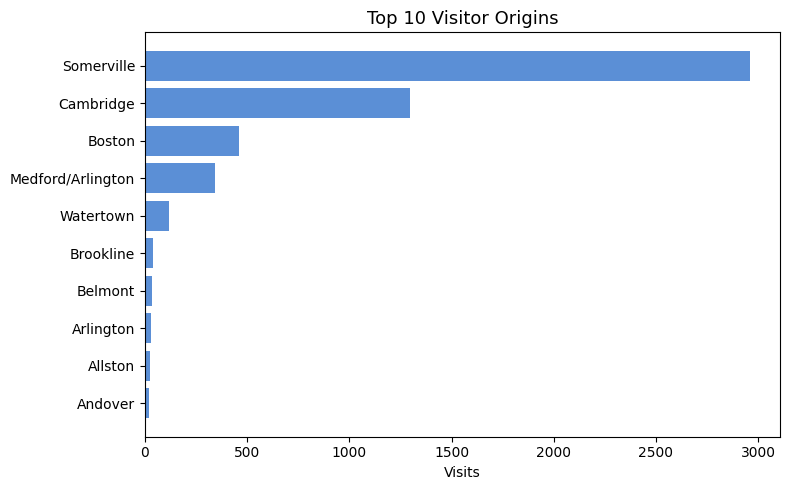

In [14]:
# Tweak TOP_N to show more or fewer origins in the chart
TOP_N = 10   # ← change this

top_origins = origins.head(TOP_N)

fig, ax = plt.subplots(figsize=(8, 5))
# [::-1] reverses the list so the longest bar appears at the top
ax.barh(top_origins.index[::-1], top_origins.values[::-1], color="#5B8FD6")
ax.set_title(f"Top {TOP_N} Visitor Origins", fontsize=13)
ax.set_xlabel("Visits")
plt.tight_layout()
plt.show()

## 6. How Visitors Arrived

In [15]:
modes = df[df["arrival_mode"] != "nan"]["arrival_mode"].value_counts()
print(modes.to_string())

arrival_mode
Cycling or walking    4728
Car or other           659
MBTA                   119


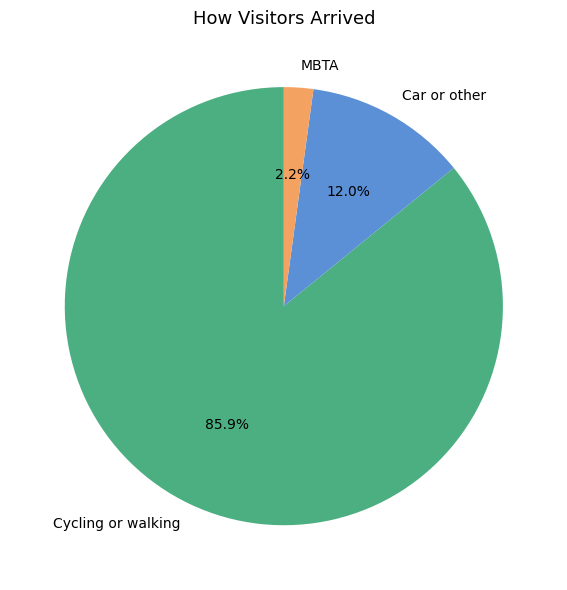

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
# autopct adds percentage labels; startangle=90 starts the first slice at 12 o'clock
ax.pie(modes.values, labels=modes.index, autopct="%1.1f%%", startangle=90,
       colors=["#4CAF82", "#5B8FD6", "#F4A261"])
ax.set_title("How Visitors Arrived", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Visit Reasons

This is a multi-select field — each row can contain several comma-separated reasons. We split them apart and count each one individually.

In [17]:
all_reasons = []

for cell in df["visit_reasons"].dropna():
    if cell != "nan":
        # split(",") breaks "Reason A, Reason B" into ["Reason A", " Reason B"]
        # strip() removes the leading space from each item
        # extend() adds each item individually to the list (not as a nested list)
        all_reasons.extend([r.strip() for r in cell.split(",")])

# Counter produces a dict-like {reason: count} mapping
reason_counts = Counter(all_reasons)

print("=== Visit Reasons (all mentions) ===")
for reason, count in reason_counts.most_common():
    print(f"  {count:>5}  {reason}")

=== Visit Reasons (all mentions) ===
   3247  Use Your Tools!
   2591  Save $ & Self-reliance
   2183  Education & Instruction
   1262  Community & Social
    979  I'm here to volunteer!
    122  Femmechanics Grrreasetime @ SBK!
     19  Parkour
     13  To save some money & become more self-reliant
     10  To learn basic mechanics or get help fixing my bike
      9  To strengthen my social circles in my local bike community
      6  
      5  Parts
      5  To learn as much as I can and eventually become a master mechanic
      4  Donate
      4  To learn basic bike mechanics or get help fixing this 1 thing on my bike
      3  Donation
      3  Flat tire
      3  Volunteer
      3  I know what I'm doing
      3  just need the tools!
      3  To help people in my community do a cool thing
      2  Cranksgiving
      2  Help with my bike
      2  Visit
      2  Donations
      2  Donate parts
      2  Help
      2  Repair
      2  Help!
      2  Fix my bike
      2  Hanging out
      1

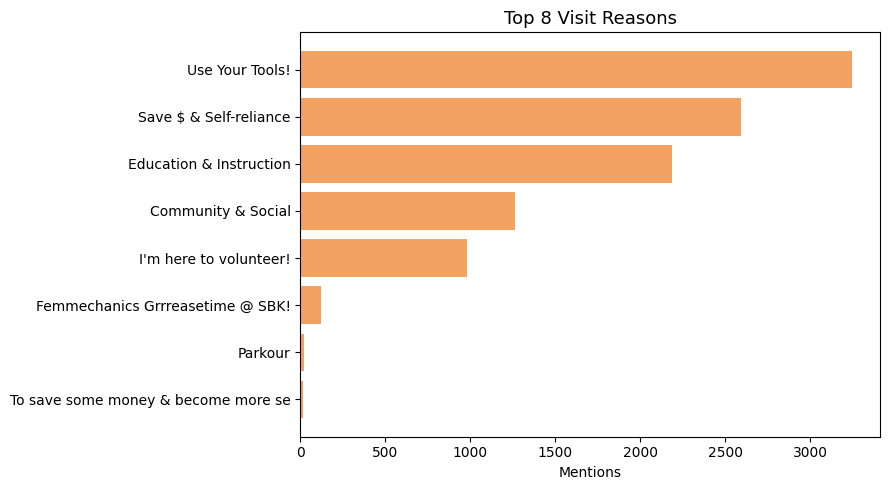

In [18]:
TOP_REASONS = 8   # ← change to show more or fewer

top_reasons = reason_counts.most_common(TOP_REASONS)

# zip(*list_of_pairs) "unzips" [(a,1),(b,2)] into (a,b) and (1,2)
labels, counts = zip(*top_reasons)
short_labels = [l[:35] for l in labels]   # truncate long labels to fit the chart

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(short_labels[::-1], counts[::-1], color="#F4A261")
ax.set_title(f"Top {TOP_REASONS} Visit Reasons", fontsize=13)
ax.set_xlabel("Mentions")
plt.tight_layout()
plt.show()

## 8. New vs. Returning Visitors

In [19]:
first_visit_counts = df["first_visit"].value_counts()
print(first_visit_counts.to_string())

total = first_visit_counts.sum()
for label, count in first_visit_counts.items():
    print(f"  {label}: {count:,} ({count/total*100:.1f}%)")

first_visit
No     3790
Yes    2347
  No: 3,790 (61.8%)
  Yes: 2,347 (38.2%)


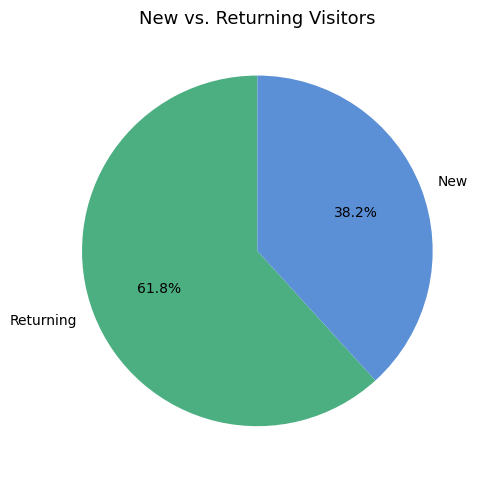

In [20]:
# Filter to just Yes/No to exclude blank/ambiguous entries
fv = df[df["first_visit"].isin(["Yes", "No"])]["first_visit"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(fv.values, labels=["Returning", "New"] if fv.index[0] == "No" else ["New", "Returning"],
       autopct="%1.1f%%", startangle=90, colors=["#4CAF82", "#5B8FD6"])
ax.set_title("New vs. Returning Visitors", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Email Opt-ins & Volunteer Interest

In [21]:
# .isin() filters to only rows with a valid Yes/No answer (excludes blanks)
opt_in = df[df["email_opt_in"].isin(["Yes", "No"])]["email_opt_in"].value_counts()
vol    = df[df["volunteer_interest"].isin(["Yes", "No"])]["volunteer_interest"].value_counts()

print("=== Email Opt-In (respondents only) ===")
print(opt_in.to_string())
print(f"  Opt-in rate: {opt_in.get('Yes', 0) / opt_in.sum() * 100:.1f}%\n")

print("=== Volunteer Interest (respondents only) ===")
print(vol.to_string())
print(f"  Interest rate: {vol.get('Yes', 0) / vol.sum() * 100:.1f}%")

=== Email Opt-In (respondents only) ===
email_opt_in
Yes    1632
No      715
  Opt-in rate: 69.5%

=== Volunteer Interest (respondents only) ===
volunteer_interest
No     1576
Yes     716
  Interest rate: 31.2%


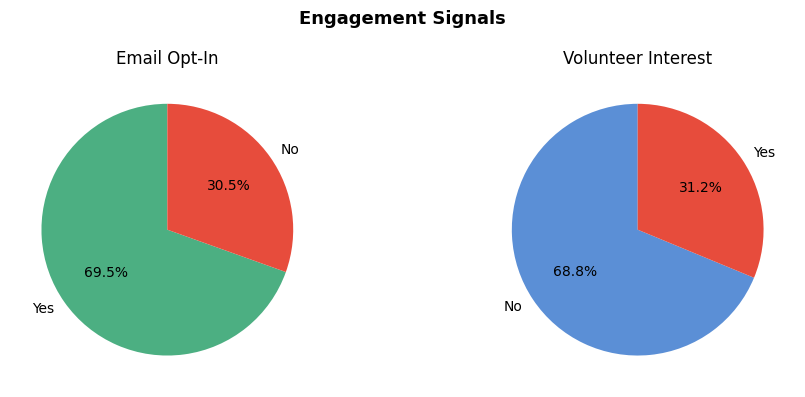

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].pie(opt_in.values, labels=opt_in.index, autopct="%1.1f%%",
            startangle=90, colors=["#4CAF82", "#E74C3C"])
axes[0].set_title("Email Opt-In")

axes[1].pie(vol.values, labels=vol.index, autopct="%1.1f%%",
            startangle=90, colors=["#5B8FD6", "#E74C3C"])
axes[1].set_title("Volunteer Interest")

plt.suptitle("Engagement Signals", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Peak Sign-In Hours

In [23]:
# .sort_index() sorts by hour number (0–23) rather than by frequency
peak = df["hour"].value_counts().sort_index()
print(peak.to_string())

hour
0        1
1        2
2        1
7        4
8       16
9       29
10      27
11      22
12      17
13      24
14      17
15      26
16       9
17     147
18    3163
19    1791
20     696
21     123
22      11
23      11


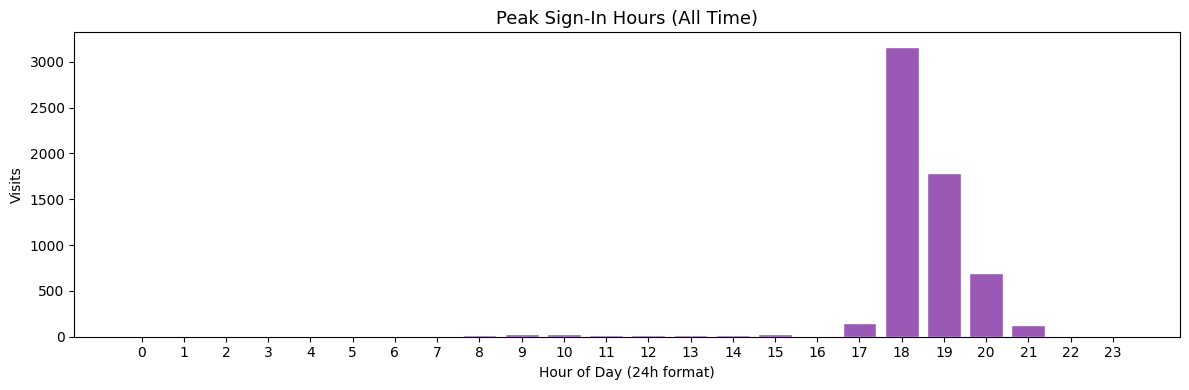

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(peak.index, peak.values, color="#9B59B6", edgecolor="white")
ax.set_title("Peak Sign-In Hours (All Time)", fontsize=13)
ax.set_xlabel("Hour of Day (24h format)")
ax.set_ylabel("Visits")
ax.set_xticks(range(0, 24))   # force a tick for every hour
plt.tight_layout()
plt.show()

## 11. Unique Visitors per Year
Total sign-ins counts every visit. This section counts distinct individuals (by email) per year.

In [25]:
# groupby year, then nunique on the email column = distinct visitors per year
unique_per_year = df.groupby("year")["email"].nunique()
total_per_year  = df.groupby("year").size()

comparison = pd.DataFrame({
    "Total Sign-ins": total_per_year,
    "Unique Visitors": unique_per_year,
})
# Avg visits per unique visitor
comparison["Avg Visits/Person"] = (comparison["Total Sign-ins"] / comparison["Unique Visitors"]).round(1)

comparison

,Total Sign-ins,Unique Visitors,Avg Visits/Person
year,,,
2019,266,191,1.4
2021,2,2,1.0
2022,368,237,1.6
2023,1293,697,1.9
2024,1748,930,1.9
2025,2214,1238,1.8
2026,246,177,1.4


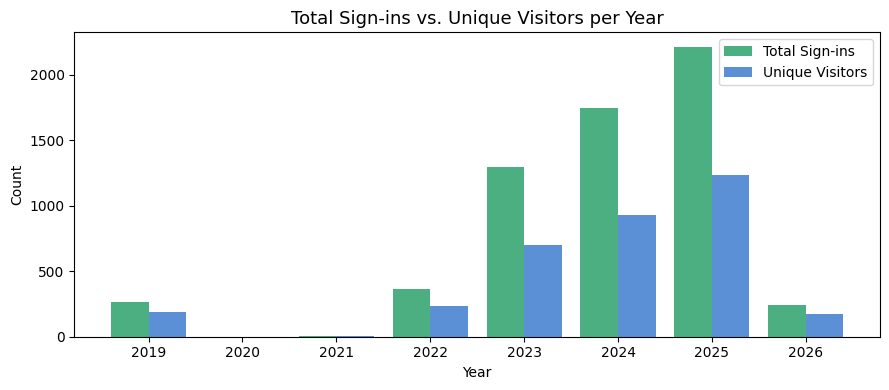

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))

x = comparison.index
width = 0.4

# Side-by-side bars: offset each group by half a bar width
ax.bar(x - width/2, comparison["Total Sign-ins"],  width, label="Total Sign-ins",  color="#4CAF82")
ax.bar(x + width/2, comparison["Unique Visitors"], width, label="Unique Visitors", color="#5B8FD6")

ax.set_title("Total Sign-ins vs. Unique Visitors per Year", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## 12. All Charts Together
Renders and saves all 6 charts as a single image — useful for sharing or reporting.

✅ Saved to /kaggle/working/SBK_Visitor_Analysis.png


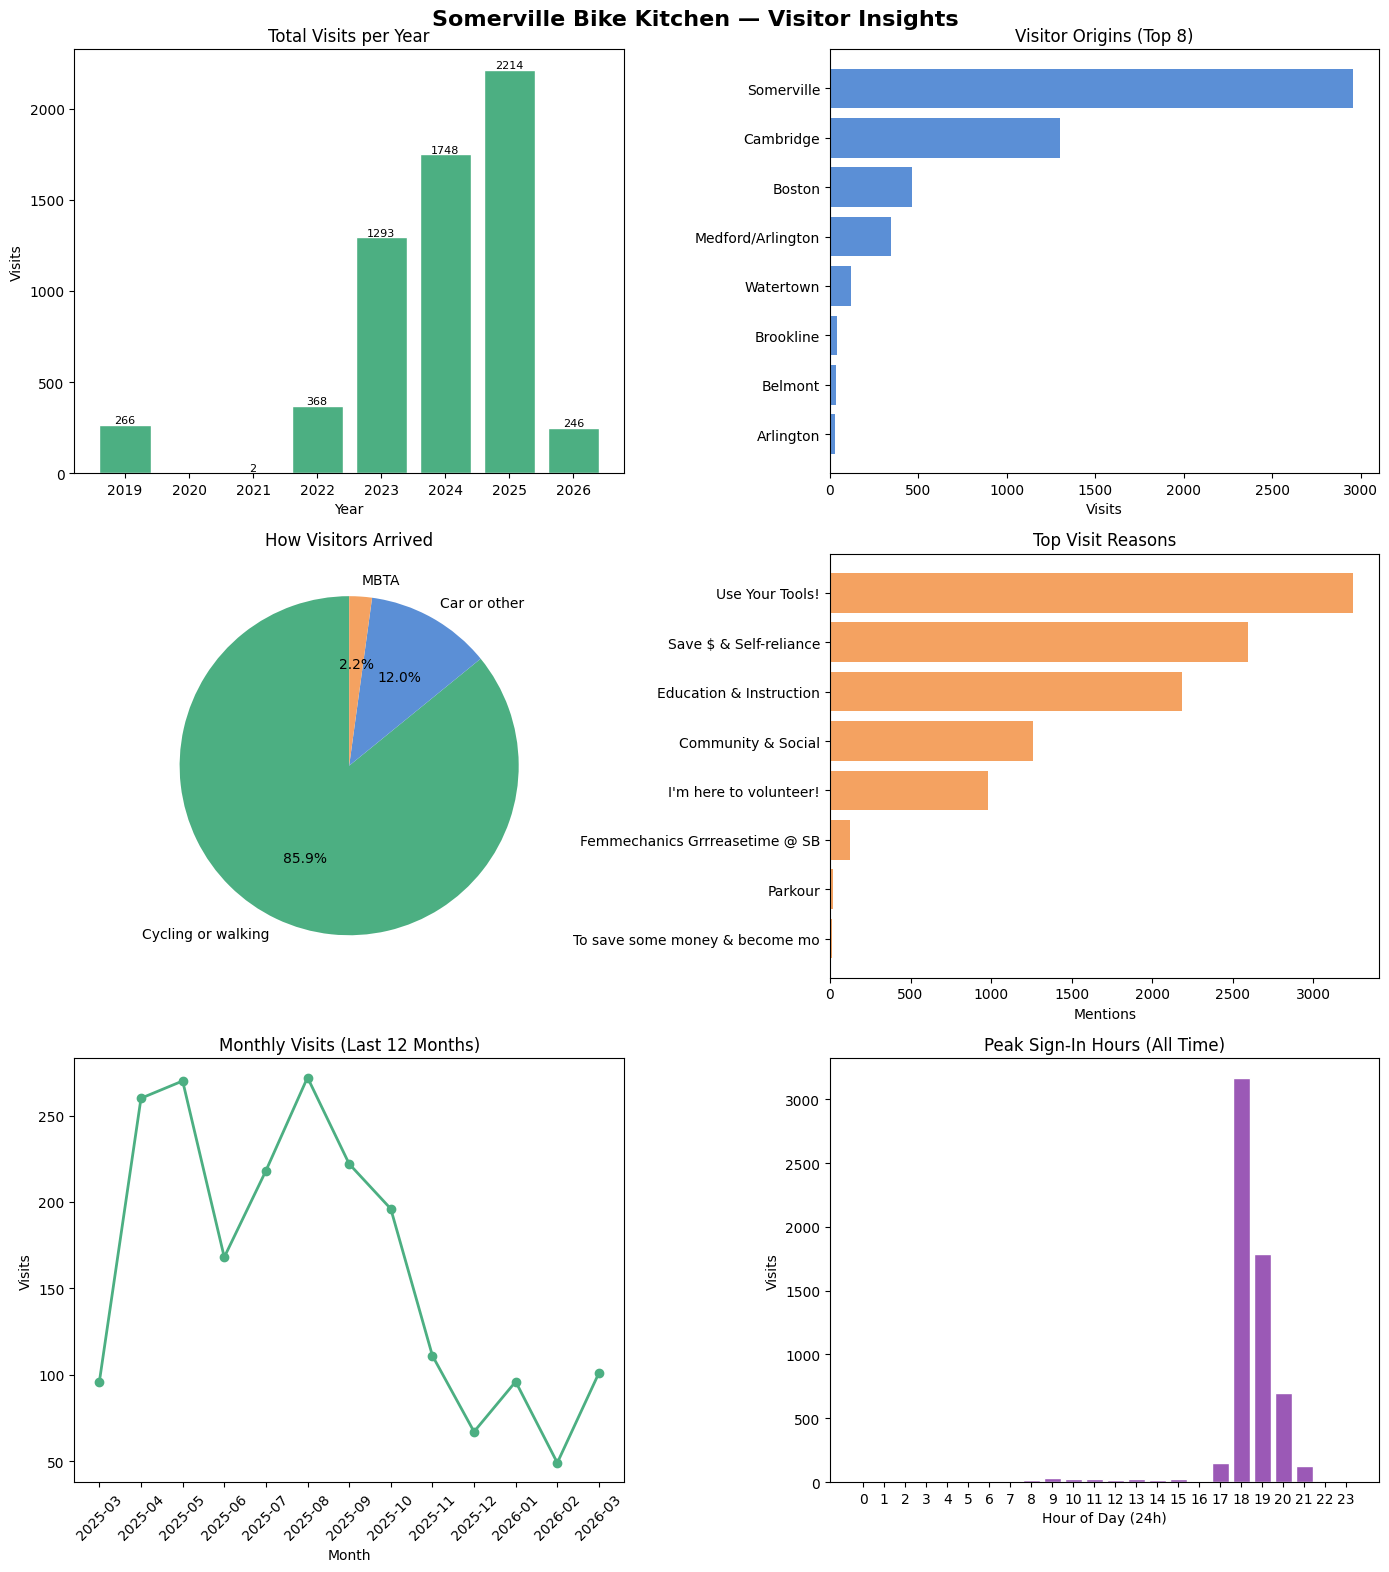

In [27]:
# ── UPDATE THIS PATH to choose where the image is saved ──────────────────────
OUTPUT_PATH = "/kaggle/working/SBK_Visitor_Analysis.png"
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle("Somerville Bike Kitchen — Visitor Insights", fontsize=16, fontweight="bold", y=0.98)

# Chart 1: Visits per year
ax = axes[0, 0]
yearly = df.groupby("year").size()
bars = ax.bar(yearly.index, yearly.values, color="#4CAF82", edgecolor="white")
ax.set_title("Total Visits per Year")
ax.set_xlabel("Year"); ax.set_ylabel("Visits")
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha="center", fontsize=8)

# Chart 2: Top origins
ax = axes[0, 1]
top_origins = origins.head(8)
ax.barh(top_origins.index[::-1], top_origins.values[::-1], color="#5B8FD6")
ax.set_title("Visitor Origins (Top 8)")
ax.set_xlabel("Visits")

# Chart 3: Arrival mode
ax = axes[1, 0]
ax.pie(modes.values, labels=modes.index, autopct="%1.1f%%", startangle=90,
       colors=["#4CAF82", "#5B8FD6", "#F4A261"])
ax.set_title("How Visitors Arrived")

# Chart 4: Visit reasons
ax = axes[1, 1]
top_r = reason_counts.most_common(8)
rlabels, rcounts = zip(*top_r)
ax.barh([l[:30] for l in rlabels][::-1], list(rcounts)[::-1], color="#F4A261")
ax.set_title("Top Visit Reasons")
ax.set_xlabel("Mentions")

# Chart 5: Monthly trend
ax = axes[2, 0]
ax.plot(monthly.index.astype(str), monthly.values, marker="o", color="#4CAF82", linewidth=2)
ax.set_title("Monthly Visits (Last 12 Months)")
ax.set_xlabel("Month"); ax.set_ylabel("Visits")
ax.tick_params(axis="x", rotation=45)

# Chart 6: Peak hours
ax = axes[2, 1]
ax.bar(peak.index, peak.values, color="#9B59B6", edgecolor="white")
ax.set_title("Peak Sign-In Hours (All Time)")
ax.set_xlabel("Hour of Day (24h)"); ax.set_ylabel("Visits")
ax.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
print(f"✅ Saved to {OUTPUT_PATH}")
plt.show()